In [1]:
# CELL 1 — Imports & Style Setup
# Loads all libraries and sets a dark professional chart theme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0D1117',
    'axes.facecolor': '#161B22',
    'axes.edgecolor': '#21262D',
    'axes.labelcolor': '#C9D1D9',
    'xtick.color': '#8B949E',
    'ytick.color': '#8B949E',
    'grid.color': '#21262D',
    'grid.alpha': 0.7,
    'text.color': '#E6EDF3',
    'font.family': 'DejaVu Sans',
    'axes.titlepad': 14,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})
COLORS = ['#58A6FF', '#3FB950', '#FF7B72', '#D2A8FF', '#FFA657']
DEPT_COLORS = {'Engineering':'#58A6FF','Sales':'#3FB950','HR':'#FF7B72',
               'Finance':'#D2A8FF','Marketing':'#FFA657','Operations':'#79C0FF'}
print("✅ Libraries loaded. Dark theme configured.")

✅ Libraries loaded. Dark theme configured.


In [2]:
# CELL 2 — Generate Synthetic HR Dataset
# Creates 1000 realistic employee records with 12 features.
# Performance label is calculated from real-world weighted logic.
np.random.seed(42)
N = 1000
departments = ['Engineering','Sales','HR','Finance','Marketing','Operations']
edu_levels  = ['Bachelor','Master','PhD','Diploma']

df = pd.DataFrame({
    'employee_id'      : [f'EMP{i:04d}' for i in range(1, N+1)],
    'age'              : np.random.randint(22, 58, N),
    'gender'           : np.random.choice(['Male','Female'], N, p=[0.58, 0.42]),
    'department'       : np.random.choice(departments, N, p=[0.28,0.20,0.12,0.15,0.13,0.12]),
    'education'        : np.random.choice(edu_levels, N, p=[0.45,0.30,0.10,0.15]),
    'experience_years' : np.random.randint(0, 30, N),
    'monthly_salary'   : np.random.randint(25000, 120000, N),
    'training_hours'   : np.random.randint(0, 80, N),
    'projects_done'    : np.random.randint(1, 25, N),
    'attendance_pct'   : np.round(np.random.uniform(70, 100, N), 1),
    'overtime_hours'   : np.random.randint(0, 40, N),
    'satisfaction_score': np.round(np.random.uniform(1, 5, N), 1),
    'manager_rating'   : np.round(np.random.uniform(1, 5, N), 1),
})

# Realistic performance score
df['perf_score'] = (
    df['training_hours']     * 0.30 +
    df['projects_done']      * 1.20 +
    df['attendance_pct']     * 0.25 +
    df['satisfaction_score'] * 3.50 +
    df['manager_rating']     * 4.00 +
    df['experience_years']   * 0.40 +
    np.random.normal(0, 8, N)
)

pct = df['perf_score'].quantile([0.33, 0.67])
df['performance'] = df['perf_score'].apply(
    lambda x: 'Low' if x <= pct[0.33] else ('Medium' if x <= pct[0.67] else 'High'))
df.drop(columns=['perf_score'], inplace=True)
df.to_csv('employee_data.csv', index=False)

print(f"✅ Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📊 Performance Distribution: {df['performance'].value_counts().to_dict()}")
df.head(6)

✅ Dataset: 1,000 rows × 14 columns
📊 Performance Distribution: {'Medium': 340, 'Low': 330, 'High': 330}


,employee_id,age,gender,department,education,experience_years,monthly_salary,training_hours,projects_done,attendance_pct,overtime_hours,satisfaction_score,manager_rating,performance
0,EMP0001,50,Female,HR,Master,11,94806,18,8,89.7,37,2.3,1.7,Low
1,EMP0002,36,Male,Marketing,Master,3,67814,57,18,80.2,21,3.3,4.9,High
2,EMP0003,29,Female,Marketing,Master,28,95219,22,13,92.4,33,1.3,3.9,Low
3,EMP0004,42,Female,Marketing,Bachelor,22,74646,53,21,86.5,18,4.3,3.5,High
4,EMP0005,40,Female,Engineering,Bachelor,5,64884,79,9,83.6,19,3.2,1.2,Medium
5,EMP0006,44,Female,Finance,Master,9,94322,64,10,75.1,13,3.7,4.5,Medium


In [3]:
# CELL 3 — Data Overview & Stats
# Quick sanity check on the data before analysis.
print("="*55)
print("  HR DATASET OVERVIEW")
print("="*55)
print(f"\n🔢 Shape      : {df.shape}")
print(f"❌ Null values : {df.isnull().sum().sum()}")
print(f"🏢 Departments : {list(df['department'].unique())}")
print(f"👥 Gender split: {df['gender'].value_counts().to_dict()}")
print(f"🎓 Education   : {df['education'].value_counts().to_dict()}")
print("\n📊 Numerical Summary:")
df[['age','experience_years','monthly_salary','training_hours',
    'satisfaction_score','manager_rating']].describe().round(2)

  HR DATASET OVERVIEW

🔢 Shape      : (1000, 14)
❌ Null values : 0
🏢 Departments : ['HR', 'Marketing', 'Engineering', 'Finance', 'Sales', 'Operations']
👥 Gender split: {'Male': 573, 'Female': 427}
🎓 Education   : {'Bachelor': 438, 'Master': 310, 'Diploma': 149, 'PhD': 103}

📊 Numerical Summary:


,age,experience_years,monthly_salary,training_hours,satisfaction_score,manager_rating
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,39.93,14.71,70494.66,40.75,3.02,3.00
std,10.67,8.42,28009.57,23.25,1.14,1.16
min,22.00,0.00,25060.00,0.00,1.00,1.00
25%,30.00,8.00,46038.75,21.00,2.10,2.00
50%,41.00,14.00,68748.50,41.00,3.00,3.00
75%,49.00,22.00,95508.00,61.00,4.00,4.00
max,57.00,29.00,119948.00,79.00,5.00,5.00


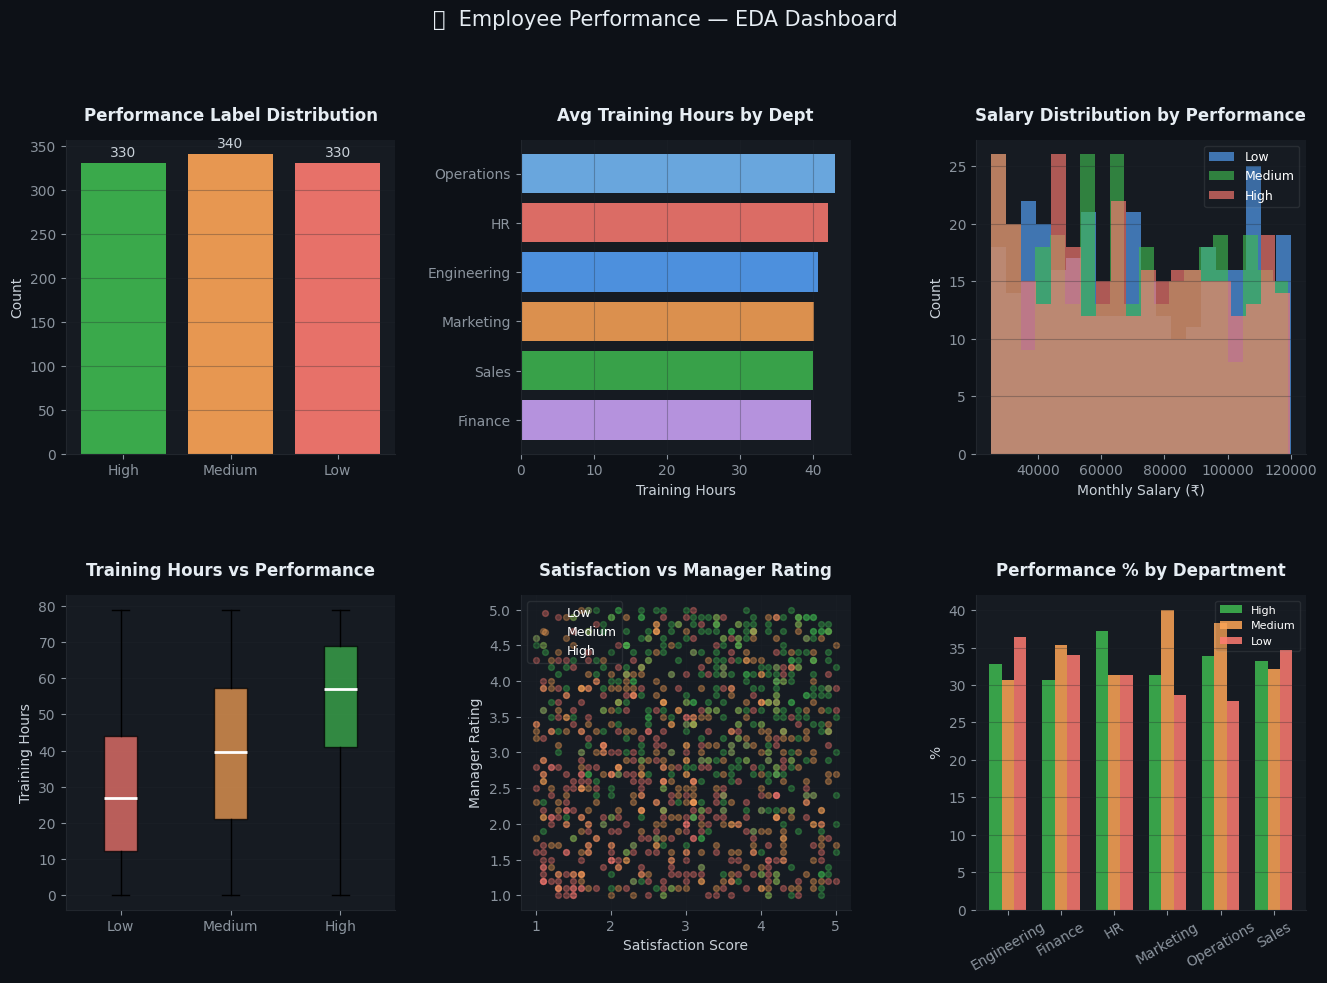

💾 Saved: chart1_eda_dashboard.png


In [4]:
# CELL 4 — EDA Dashboard (6 Charts in 1 Figure)
# One combined figure with 6 charts covering all key HR metrics.
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0D1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Chart A — Performance distribution
ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor('#161B22')
perf_counts = df['performance'].value_counts()[['High','Medium','Low']]
bars = ax1.bar(perf_counts.index, perf_counts.values,
               color=['#3FB950','#FFA657','#FF7B72'], edgecolor='none', alpha=0.9)
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+8,
             str(b.get_height()), ha='center', color='#C9D1D9', fontsize=10)
ax1.set_title('Performance Label Distribution')
ax1.set_ylabel('Count')
ax1.grid(True, axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Chart B — Training hours by department
ax2 = fig.add_subplot(gs[0,1]); ax2.set_facecolor('#161B22')
dept_perf = df.groupby('department')['training_hours'].mean().sort_values()
colors_d  = [DEPT_COLORS[d] for d in dept_perf.index]
ax2.barh(dept_perf.index, dept_perf.values, color=colors_d, alpha=0.85, edgecolor='none')
ax2.set_title('Avg Training Hours by Dept')
ax2.set_xlabel('Training Hours')
ax2.grid(True, axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Chart C — Salary distribution by performance
ax3 = fig.add_subplot(gs[0,2]); ax3.set_facecolor('#161B22')
for i, perf in enumerate(['Low','Medium','High']):
    ax3.hist(df[df['performance']==perf]['monthly_salary'], bins=20,
             alpha=0.65, color=COLORS[i], label=perf, edgecolor='none')
ax3.set_title('Salary Distribution by Performance')
ax3.set_xlabel('Monthly Salary (₹)'); ax3.set_ylabel('Count')
ax3.legend(framealpha=0.1, labelcolor='white', fontsize=9)
ax3.grid(True, axis='y', alpha=0.3)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

# Chart D — Training hours boxplot
ax4 = fig.add_subplot(gs[1,0]); ax4.set_facecolor('#161B22')
bp = ax4.boxplot([df[df['performance']==p]['training_hours'].values for p in ['Low','Medium','High']],
                 labels=['Low','Medium','High'], patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], ['#FF7B72','#FFA657','#3FB950']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax4.set_title('Training Hours vs Performance')
ax4.set_ylabel('Training Hours')
ax4.grid(True, axis='y', alpha=0.3)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

# Chart E — Satisfaction vs Manager Rating scatter
ax5 = fig.add_subplot(gs[1,1]); ax5.set_facecolor('#161B22')
colors_map = {'Low':'#FF7B72','Medium':'#FFA657','High':'#3FB950'}
for perf in ['Low','Medium','High']:
    sub = df[df['performance']==perf]
    ax5.scatter(sub['satisfaction_score'], sub['manager_rating'],
                alpha=0.35, s=18, color=colors_map[perf], label=perf)
ax5.set_title('Satisfaction vs Manager Rating')
ax5.set_xlabel('Satisfaction Score'); ax5.set_ylabel('Manager Rating')
ax5.legend(framealpha=0.1, labelcolor='white', fontsize=9)
ax5.grid(True, alpha=0.2)
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

# Chart F — Performance % by Department
ax6 = fig.add_subplot(gs[1,2]); ax6.set_facecolor('#161B22')
cross = pd.crosstab(df['department'], df['performance'], normalize='index')[['High','Medium','Low']] * 100
cross.plot(kind='bar', ax=ax6, color=['#3FB950','#FFA657','#FF7B72'],
           alpha=0.85, edgecolor='none', width=0.7)
ax6.set_title('Performance % by Department')
ax6.set_xlabel(''); ax6.set_ylabel('%')
ax6.tick_params(axis='x', rotation=30)
ax6.legend(framealpha=0.1, labelcolor='white', fontsize=8)
ax6.grid(True, axis='y', alpha=0.3)
ax6.spines['top'].set_visible(False); ax6.spines['right'].set_visible(False)

fig.suptitle('👥  Employee Performance — EDA Dashboard', fontsize=15, color='#E6EDF3', y=1.01)
plt.tight_layout()
plt.savefig('chart1_eda_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("💾 Saved: chart1_eda_dashboard.png")

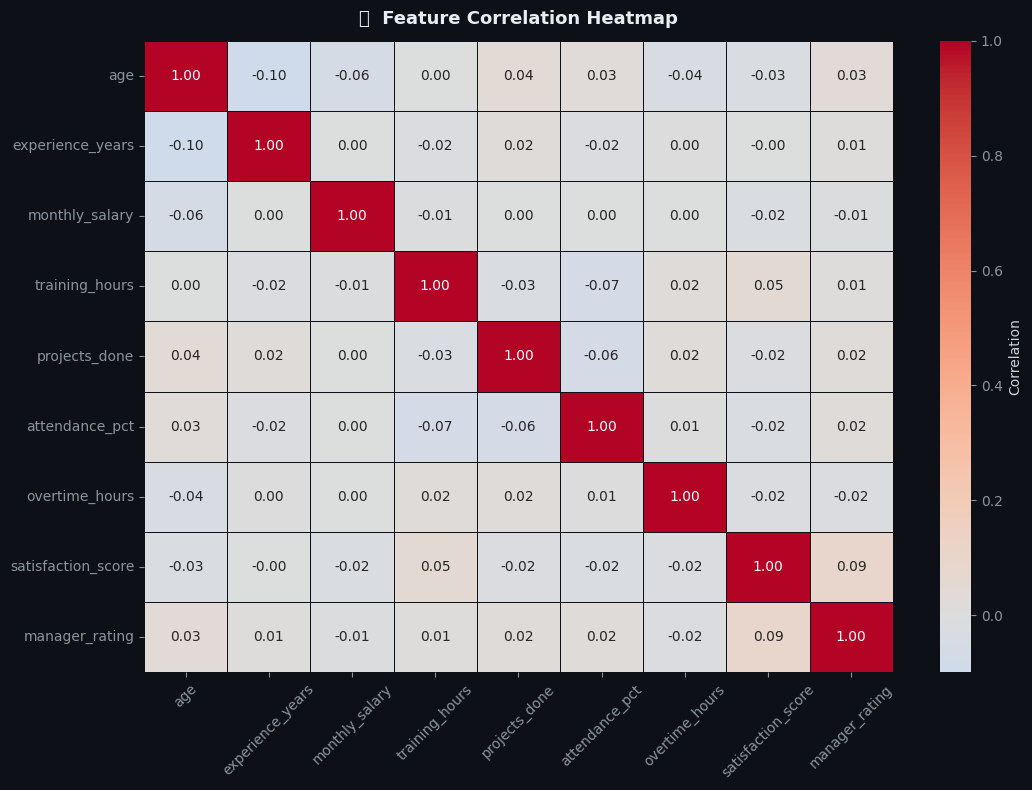

💾 Saved: chart2_correlation.png


In [5]:
# CELL 5 — Correlation Heatmap
# Shows which numeric features are strongly related to each other.
num_cols = ['age','experience_years','monthly_salary','training_hours',
            'projects_done','attendance_pct','overtime_hours','satisfaction_score','manager_rating']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, linecolor='#0D1117', ax=ax,
            cbar_kws={'label': 'Correlation'})
ax.set_title('🔗  Feature Correlation Heatmap', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('chart2_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("💾 Saved: chart2_correlation.png")

In [6]:
# CELL 6 — Feature Engineering & Preprocessing
# Encodes categorical columns, scales features, splits data 80/20.
df_ml = df.drop(columns=['employee_id']).copy()

le_dept = LabelEncoder(); df_ml['department']  = le_dept.fit_transform(df_ml['department'])
le_edu  = LabelEncoder(); df_ml['education']   = le_edu.fit_transform(df_ml['education'])
le_gen  = LabelEncoder(); df_ml['gender']      = le_gen.fit_transform(df_ml['gender'])
le_perf = LabelEncoder(); df_ml['performance'] = le_perf.fit_transform(df_ml['performance'])

FEATURES = [c for c in df_ml.columns if c != 'performance']
X = df_ml[FEATURES]
y = df_ml['performance']

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Preprocessing complete")
print(f"   Features      : {FEATURES}")
print(f"   Train size    : {X_train.shape[0]} samples")
print(f"   Test size     : {X_test.shape[0]} samples")
print(f"   Target classes: {list(le_perf.classes_)}")

✅ Preprocessing complete
   Features      : ['age', 'gender', 'department', 'education', 'experience_years', 'monthly_salary', 'training_hours', 'projects_done', 'attendance_pct', 'overtime_hours', 'satisfaction_score', 'manager_rating']
   Train size    : 800 samples
   Test size     : 200 samples
   Target classes: ['High', 'Low', 'Medium']


In [7]:
# CELL 7 — Train ML Models
# Trains Random Forest and Logistic Regression. Prints accuracy for both.
models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
}
results = {}

print("Training models...\n")
print(f"{'Model':<26} {'Accuracy':>10}")
print("-"*40)
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc  = accuracy_score(y_test, pred)
    results[name] = {'model': model, 'pred': pred, 'acc': acc}
    print(f"{name:<26} {acc*100:>9.2f}%")

best_name  = max(results, key=lambda k: results[k]['acc'])
best_model = results[best_name]['model']
best_pred  = results[best_name]['pred']
best_acc   = results[best_name]['acc']

print(f"\n🏆 Best Model: {best_name}  →  {best_acc*100:.2f}% Accuracy")
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, best_pred, target_names=le_perf.classes_))

Training models...

Model                        Accuracy
----------------------------------------
Random Forest                  64.00%
Logistic Regression            66.00%

🏆 Best Model: Logistic Regression  →  66.00% Accuracy

📋 Detailed Classification Report:
              precision    recall  f1-score   support

        High       0.73      0.74      0.74        66
         Low       0.74      0.73      0.73        66
      Medium       0.51      0.51      0.51        68

    accuracy                           0.66       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.66      0.66      0.66       200



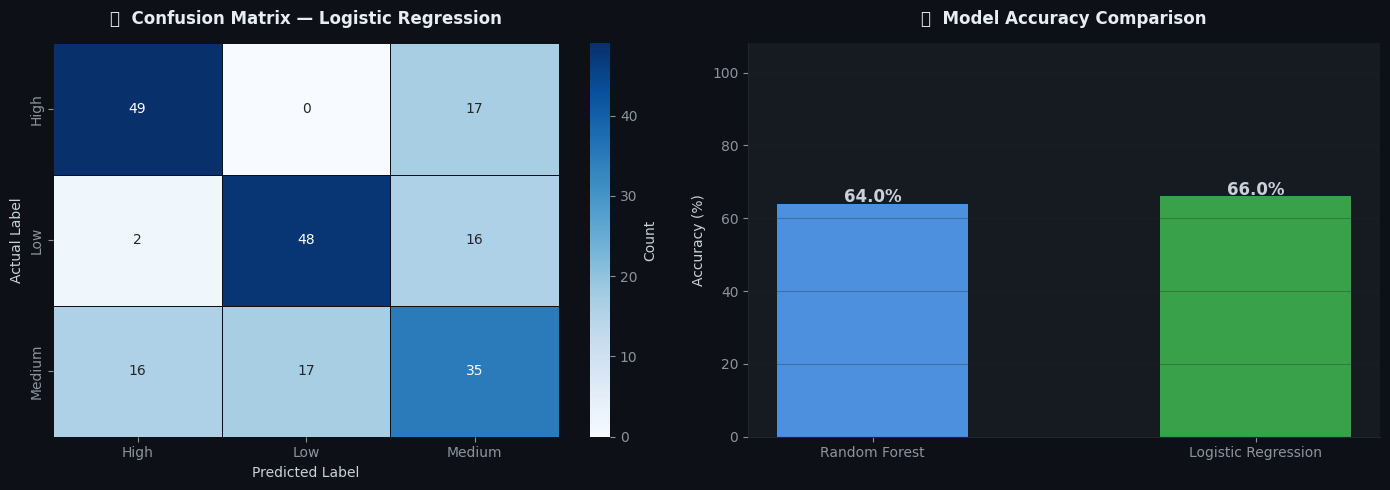

💾 Saved: chart3_model_evaluation.png


In [8]:
# CELL 8 — Confusion Matrix + Model Comparison Chart
# Visual proof of model performance — the most important screenshot for GitHub.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_perf.classes_, yticklabels=le_perf.classes_,
            linewidths=0.5, linecolor='#0D1117', ax=ax1,
            cbar_kws={'label': 'Count'})
ax1.set_title(f'🎯  Confusion Matrix — {best_name}', fontsize=12)
ax1.set_xlabel('Predicted Label'); ax1.set_ylabel('Actual Label')

# Accuracy comparison bar
model_names = list(results.keys())
accs = [results[m]['acc']*100 for m in model_names]
bar_colors = ['#3FB950' if a == max(accs) else '#58A6FF' for a in accs]
bars = ax2.bar(model_names, accs, color=bar_colors, alpha=0.85, edgecolor='none', width=0.5)
for b, a in zip(bars, accs):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
             f'{a:.1f}%', ha='center', color='#C9D1D9', fontsize=12, fontweight='bold')
ax2.set_title('📊  Model Accuracy Comparison')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 108)
ax2.grid(True, axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_model_evaluation.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("💾 Saved: chart3_model_evaluation.png")

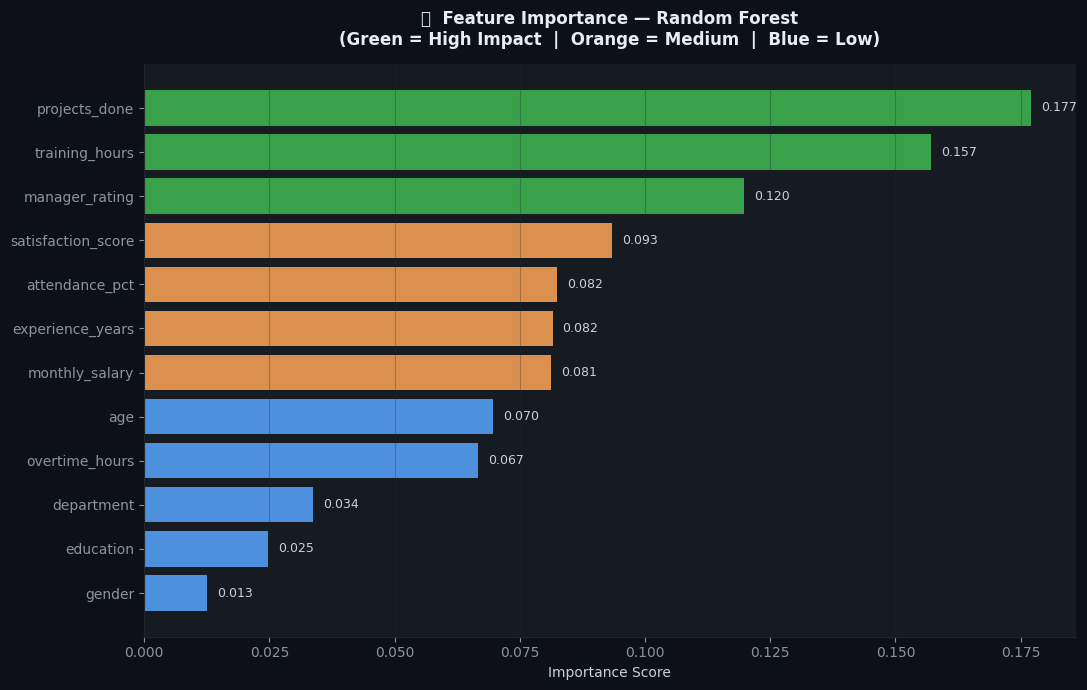

💾 Saved: chart4_feature_importance.png

🥇 Top 3 Predictors:
   projects_done             → 0.1771
   training_hours            → 0.1571
   manager_rating            → 0.1198


In [9]:
# CELL 9 — Feature Importance Chart
# Shows which features matter most for predicting performance. Key for interviews.
rf_model    = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
colors_fi = ['#3FB950' if v >= importances.quantile(0.75) else
             '#FFA657' if v >= importances.quantile(0.40) else '#58A6FF'
             for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors_fi, alpha=0.85, edgecolor='none')
ax.set_title('🔍  Feature Importance — Random Forest\n(Green = High Impact  |  Orange = Medium  |  Blue = Low)',
             fontsize=12)
ax.set_xlabel('Importance Score')
ax.grid(True, axis='x', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='#C9D1D9', fontsize=9)

plt.tight_layout()
plt.savefig('chart4_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("💾 Saved: chart4_feature_importance.png")
print(f"\n🥇 Top 3 Predictors:")
for feat, val in importances.sort_values(ascending=False).head(3).items():
    print(f"   {feat:<25} → {val:.4f}")

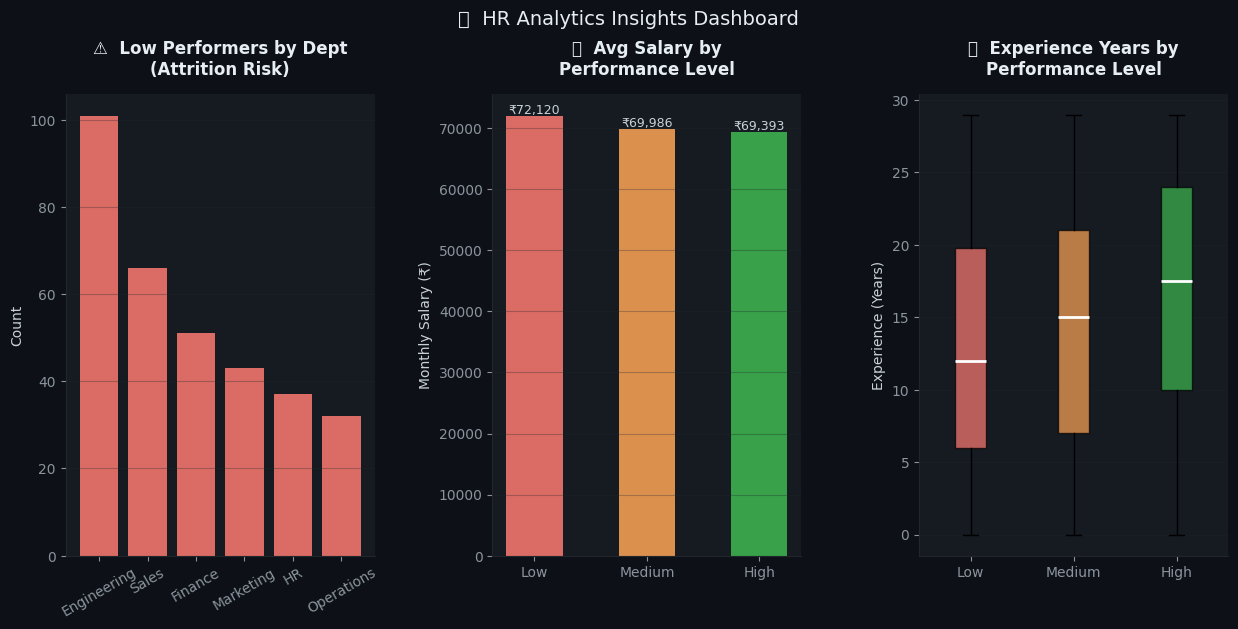

💾 Saved: chart5_hr_insights.png


In [10]:
# CELL 10 — HR Insights Dashboard
# 3 business-level charts HR teams would actually use.
fig = plt.figure(figsize=(15, 6))
fig.patch.set_facecolor('#0D1117')
gs2 = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Attrition risk by dept
ax_a = fig.add_subplot(gs2[0]); ax_a.set_facecolor('#161B22')
low_by_dept = df[df['performance']=='Low'].groupby('department').size().sort_values(ascending=False)
ax_a.bar(low_by_dept.index, low_by_dept.values, color='#FF7B72', alpha=0.85, edgecolor='none')
ax_a.set_title('⚠️  Low Performers by Dept\n(Attrition Risk)')
ax_a.set_ylabel('Count')
ax_a.tick_params(axis='x', rotation=30)
ax_a.grid(True, axis='y', alpha=0.3)
ax_a.spines['top'].set_visible(False); ax_a.spines['right'].set_visible(False)

# Avg salary by performance
ax_b = fig.add_subplot(gs2[1]); ax_b.set_facecolor('#161B22')
avg_sal = df.groupby('performance')['monthly_salary'].mean()[['Low','Medium','High']]
bars_s  = ax_b.bar(avg_sal.index, avg_sal.values,
                   color=['#FF7B72','#FFA657','#3FB950'], alpha=0.85, edgecolor='none', width=0.5)
for b, v in zip(bars_s, avg_sal.values):
    ax_b.text(b.get_x()+b.get_width()/2, v+400, f'₹{v:,.0f}',
              ha='center', color='#C9D1D9', fontsize=9)
ax_b.set_title('💰  Avg Salary by\nPerformance Level')
ax_b.set_ylabel('Monthly Salary (₹)')
ax_b.grid(True, axis='y', alpha=0.3)
ax_b.spines['top'].set_visible(False); ax_b.spines['right'].set_visible(False)

# Experience vs performance
ax_c = fig.add_subplot(gs2[2]); ax_c.set_facecolor('#161B22')
bp2 = ax_c.boxplot([df[df['performance']==p]['experience_years'].values for p in ['Low','Medium','High']],
                   labels=['Low','Medium','High'], patch_artist=True,
                   medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp2['boxes'], ['#FF7B72','#FFA657','#3FB950']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax_c.set_title('📈  Experience Years by\nPerformance Level')
ax_c.set_ylabel('Experience (Years)')
ax_c.grid(True, axis='y', alpha=0.3)
ax_c.spines['top'].set_visible(False); ax_c.spines['right'].set_visible(False)

fig.suptitle('🏢  HR Analytics Insights Dashboard', fontsize=14, color='#E6EDF3', y=1.02)
plt.tight_layout()
plt.savefig('chart5_hr_insights.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("💾 Saved: chart5_hr_insights.png")

In [11]:
# CELL 11 — Live Prediction Demo
# Predicts performance for 3 new hypothetical employees with probability scores.
sample_employees = pd.DataFrame([
    {'age':29,'gender':'Male','department':'Engineering','education':'Master',
     'experience_years':5,'monthly_salary':72000,'training_hours':55,
     'projects_done':12,'attendance_pct':95.0,'overtime_hours':10,
     'satisfaction_score':4.2,'manager_rating':4.5},
    {'age':42,'gender':'Female','department':'Sales','education':'Bachelor',
     'experience_years':18,'monthly_salary':48000,'training_hours':12,
     'projects_done':4,'attendance_pct':74.0,'overtime_hours':35,
     'satisfaction_score':2.1,'manager_rating':2.3},
    {'age':35,'gender':'Male','department':'Finance','education':'PhD',
     'experience_years':10,'monthly_salary':95000,'training_hours':40,
     'projects_done':8,'attendance_pct':88.0,'overtime_hours':5,
     'satisfaction_score':3.8,'manager_rating':4.0},
])

demo = sample_employees.copy()
demo['department'] = le_dept.transform(demo['department'])
demo['education']  = le_edu.transform(demo['education'])
demo['gender']     = le_gen.transform(demo['gender'])
demo_scaled = scaler.transform(demo)
preds = le_perf.inverse_transform(best_model.predict(demo_scaled))
probs = best_model.predict_proba(demo_scaled)

print("\n" + "="*65)
print("  LIVE PREDICTION DEMO — 3 NEW EMPLOYEES")
print("="*65)
profiles = ["ENG/Master/5yr/High Training", "Sales/Bachelor/18yr/Low Training", "Finance/PhD/10yr/Mid Training"]
for i, (_, row) in enumerate(sample_employees.iterrows()):
    prob_dict = dict(zip(le_perf.classes_, probs[i]))
    print(f"\n  Employee {i+1}: {profiles[i]}")
    print(f"  Satisfaction: {row['satisfaction_score']} | Mgr Rating: {row['manager_rating']}")
    print(f"  → Predicted: 【 {preds[i]} 】")
    print(f"     High: {prob_dict.get('High',0)*100:.1f}%  |  Medium: {prob_dict.get('Medium',0)*100:.1f}%  |  Low: {prob_dict.get('Low',0)*100:.1f}%")
print("="*65)


  LIVE PREDICTION DEMO — 3 NEW EMPLOYEES

  Employee 1: ENG/Master/5yr/High Training
  Satisfaction: 4.2 | Mgr Rating: 4.5
  → Predicted: 【 High 】
     High: 80.4%  |  Medium: 18.6%  |  Low: 1.0%

  Employee 2: Sales/Bachelor/18yr/Low Training
  Satisfaction: 2.1 | Mgr Rating: 2.3
  → Predicted: 【 Low 】
     High: 0.0%  |  Medium: 3.2%  |  Low: 96.8%

  Employee 3: Finance/PhD/10yr/Mid Training
  Satisfaction: 3.8 | Mgr Rating: 4.0
  → Predicted: 【 Medium 】
     High: 22.3%  |  Medium: 53.5%  |  Low: 24.2%


In [12]:
# CELL 12 — Final Report Summary
# Boxed summary of all results — screenshot this for GitHub README.
report = classification_report(y_test, best_pred, target_names=le_perf.classes_, output_dict=True)

print()
print("╔══════════════════════════════════════════════════════╗")
print("║    EMPLOYEE PERFORMANCE PREDICTOR — FINAL REPORT    ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  👥 Total Employees      : {1000:<27}║")
print(f"║  📊 Features Used        : {len(FEATURES):<27}║")
print(f"║  🤖 Models Trained       : Random Forest + Logistic Reg  ║")
print(f"║  🏆 Best Model           : {best_name:<27}║")
print(f"║  🎯 Best Accuracy        : {best_acc*100:.2f}%{'':<22}║")
print("╠══════════════════════════════════════════════════════╣")
for cls in le_perf.classes_:
    prec = report[cls]['precision']
    rec  = report[cls]['recall']
    f1   = report[cls]['f1-score']
    print(f"║  [{cls:<6}] P:{prec:.2f}  R:{rec:.2f}  F1:{f1:.2f}{'':<18}║")
print("╠══════════════════════════════════════════════════════╣")
print("║  📁 Output Files:                                    ║")
print("║     employee_data.csv                               ║")
print("║     chart1_eda_dashboard.png                        ║")
print("║     chart2_correlation.png                          ║")
print("║     chart3_model_evaluation.png                     ║")
print("║     chart4_feature_importance.png                   ║")
print("║     chart5_hr_insights.png                          ║")
print("╚══════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════╗
║    EMPLOYEE PERFORMANCE PREDICTOR — FINAL REPORT    ║
╠══════════════════════════════════════════════════════╣
║  👥 Total Employees      : 1000                       ║
║  📊 Features Used        : 12                         ║
║  🤖 Models Trained       : Random Forest + Logistic Reg  ║
║  🏆 Best Model           : Logistic Regression        ║
║  🎯 Best Accuracy        : 66.00%                      ║
╠══════════════════════════════════════════════════════╣
║  [High  ] P:0.73  R:0.74  F1:0.74                  ║
║  [Low   ] P:0.74  R:0.73  F1:0.73                  ║
║  [Medium] P:0.51  R:0.51  F1:0.51                  ║
╠══════════════════════════════════════════════════════╣
║  📁 Output Files:                                    ║
║     employee_data.csv                               ║
║     chart1_eda_dashboard.png                        ║
║     chart2_correlation.png                          ║
║     chart3_model_evaluation.png    